# Load libraries

In [2]:
from project_config import load_user_paths
USER_PATHS = load_user_paths()

%load_ext autoreload
%autoreload 2



# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt

#Important!! Make sure your current directory is the MHDTurbPy folder!
os.chdir(USER_PATHS['repo_root'])


# Make sure to use the local spedas
sys.path.insert(0, os.path.join(os.getcwd(), 'pyspedas'))
import pyspedas
from pyspedas.utilities import time_string
from pytplot import get_data
from joblib import Parallel, delayed

""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))
import calc_diagnostics as calc
import TurbPy as turb
import general_functions as func
import Figures as figs

from   SEA import SEA
import three_D_funcs as threeD
import download_data as download

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/3d_anis_analysis_toolboox'))
import collect_wave_coeffs 
import data_analysis 



os.environ["CDF_LIB"] = "/Applications/cdf/cdf/lib"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Download data

In [47]:
from project_config import load_user_paths
USER_PATHS = load_user_paths()

"""
mre_run_psp.py

Minimal-but-complete MRE to run the refactored pipeline for PSP.

RUN FROM REPO ROOT (the directory that contains: pyspedas/, functions/, download_data.py)
"""

from __future__ import annotations

import os
from pathlib import Path
from joblib import Parallel, delayed

import download_data as download


# ============================================================
# 0) Environment / paths
# ============================================================

# Point this to your local CDF library (needed for some CDAS / CDF readers)
cdf_lib_path = USER_PATHS['cdf_lib_path']

# Credentials are optional (public products will still work when available).
# For private FIELDS/SWEAP products, fill these in.
credentials             =      { 'psp':{
                                           'fields': {'username': 'mvelli', 'password': 'flds@psp'},
                                           'sweap' : {'username': 'mvelli', 'password': '2019swe@pd@ta'}}}

# If you truly want no credentials:
# credentials = None


# ============================================================
# 1) Settings (tightly organized by topic)
# ============================================================

# ---- Paths / IO
PATHS = {
                "Data_path"          : USER_PATHS["Data_path"],                           # IMPORTANT: keep repo root for local imports
                "save_destination"   : USER_PATHS["save_destination"],       # where interval folders are created
}

IO = {
                "overwrite_files"               : 1,        # 1 -> overwrite folders if final.pkl exists
                "save_all"                      : True,     # True -> save final.pkl + general.pkl (+ extras)
                "addit_time_around"             : 1,        # hours padded around each interval for loading
                "gap_time_threshold"            : 5,        # legacy (used downstream)
}

# ---- Mission / geometry
MISSION = {
            "sc"                                        : "PSP",
            "in_rtn"                                    : True,                # True -> RTN output for MAG/VEL when available
}

# ---- Interval generation (LEGACY behavior kept)
# NOTE: In generate_intervals(...), "multiple_intervals" behaves as follows:
#   - multiple_intervals == False  -> ONE interval [start_date, end_date]
#   - multiple_intervals == True   -> MANY intervals using Step and duration
INTERVALS = {
    
    "start_date"              : "2021-11-15 00:00",
    "end_date"                : "2021-11-15 01:00",
    
    # if multiple intervals =True, then define duration and step
    "multiple_intervals"      : False,
    "duration"                : "4H",
    "Step"                    : "210min",
}

# ---- Sampling / resampling
SAMPLING = {
    "part_resol"          : 1,             # miliseconds
    "MAG_resol"           : 1,                # miliseconds
    "upsample_low_freq_ts": False, # keep legacy sync behavior
}

# ---- Data acceptance
QC = {
    "must_have_qtn"   : False,
    "Max_par_missing" : 30,         # % threshold used by main_function()
}

# ---- Instrument selection (PSP-specific)
PSP_INSTRUMENTS = {
    # Particle selection logic (must remain identical)
    "particle_mode"               : "span",      # {"9th_perih_cut","spc","span"}
    "allow_max_SWEAP_distance"    : False,
    "max_SWEAP_distance"          : 0.25,            # au

    # Interval rejection by distance (None -> no distance rejection)
    "max_PSP_dist": None,

    # SPAN product selection (legacy key)
    "span_key": "spi_sf00",

    # Optional Hampel filtering (kept)
    "apply_hampel": False,
    "hampel_params": {"w": 100, "std": 3},

    # Optional Orlando QTN pickle (None -> disabled)
    "orlandos_QTN": None,

}

# ---- Unified MAG noise removal (works for SOLO merged MAG and PSP SCAM)
# This is the preferred key; legacy Mag_SCAM_PSP["noise_flag"] still works.
MAG_NOISE = {
    "Mag_SCM": {
        "use_SCM"   : False,
        "noise_flag": False,
        "noise_removal": {
            'window_size'         : 2**15,
            'avg_length'          : 1,
            'power_threshold'     : 3.0,
            'freq_min'            : 10.0 # in Hz
            # "hampel_wind": 51,
            # "hampel_thresh": 3.5,
        },
    }
}

# ---- Big gap reporting thresholds (preserved)
GAPS = {
    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 10,
        "Par_big_gaps": 10,
        "QTN_big_gaps": 10,
    }
}

# ---- Optional E-field calibration block (download_data.py uses this)
E_FIELD = {
    "E_field": {
        "flag": False,
        "cadence_seconds": 6,
        "fit_interval_minutes": 4,
        "stride_minutes": 0.1,
        "min_correlation": 0.8,
        "keep_sc_pot": False,
    }
}

# ---- Optional SC potential calibration block (download_data.py uses this)
SC_POT = {
    "sc_pot": {
        "flag": False,
        "fit_window": "6000s",
        "mode": "local",        # {"local","global"} (legacy behavior)
        "overlap_ratio": 0.5,
    }
}

# ---- Downstream diagnostics toggles (kept)
DERIVED = {
    "estimate_derived_param": True,
    "rol_window": "20min",

    # optional analysis blocks used in small windows pipeline
    "PSDs"                   : {"flag":  True},
    'estimate_psd_b'         : 1,                             # Estimate magentic field powes spectral density (keep false)
    'estimate_psd_v'         : 1,                             # Estimate velocity field powes spectral density (keep false)
    'est_PSD_components'     : 1,
    'smooth_psd'             : False,
    "struc_funcs"    : {"flag": False},
                        "npt_struc_funcs": {
                            "flag"                  : False,
                            "five_points_sfunc"     : True,
                            "return_Bmod"           : True,
                            "dt_step"               : 0.25,
                            "est_sfuncs"            : False,
                            "max_qorder"            : 8,
                        },
    'coherence_analysis' : {'flag'                  : False,
                            'method'                : {'min_var': ['B'], 
                                                       'TN_only': ['B', 'E']},
                            'nv'                    : 8,
                            'alpha'                 : 3,
                            'per_thresh'            : 80,
                            'par_thresh'            : 10,
                            'coh_th'                : 0.7,
                            'num_efoldings'         : 3,
                            'njobs'                 : 10,
                            'est_mod'               : True,
                            'estimate_local_V'      : False,
                            
                            'do_coherence_analysis' : True,
                            'estimate_PSDs'         : True,
                            'estimate_coh_coeffs'   : True,
                            'estimate_comp'         : True,
                            'return_coeffs'         : False,
                            'est_sfuncs'            : False,
                            'max_qorder'            : 8
    },

    "use_hampel"     : False,
    "hampel_params"  : {"w": 200, "std": 3},

    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

# ---- Assemble flat settings dict (what the pipeline expects)
settings = {
    **PATHS,
    **IO,
    **MISSION,
    **INTERVALS,
    **SAMPLING,
    **QC,
    **PSP_INSTRUMENTS,
    **MAG_NOISE,
    **GAPS,
    **E_FIELD,
    **SC_POT,
    **DERIVED,
}


# ============================================================
# 2) Variables to download (None means "use defaults" inside PSP.py)
# ============================================================
if settings['sc'] == "PSP":
    
    if settings['in_rtn']:
        vars_2_downnload = {
                            'mag'    : None, 
                            'span'   : None,
                            'span-a' : None,
                            'spc'    : None, 
                            'qtn'    : None,
                            'E_field': settings['E_field']['flag'],
                            'sc_pot' : settings['sc_pot']['flag'],
                            'ephem'  : None}
    else:
        vars_2_downnload        = {  
                                    'mag'     : ['B_SC'],
                                    'span'    : ['DENS',  'VEL_SC', 'TEMP' , 'SUN_DIST'],
                                    'span-a'  : None,
                                    'spc'     : ['np_moment', 'wp_moment', 'vp_moment_SC','sc_pos_HCI'],
                                    'qtn'     : ['electron_density'],
            
                                    'E_field' : settings['E_field']['flag'],
                                    'sc_pot'  : settings['sc_pot']['flag'],
            
            
                                    'ephem'   : None}      

elif settings['sc'] == "SOLO":
    vars_2_downnload = {
                        'mag'    : None,
                        'swa'    : None, 
                        'rpw'    : None, # Default is 'bia-density-10-seconds', but  'bia-density' is also available and probaly interesting
                        'ephem'  : None} 
else:
    
    print('Not ready yet!')
    

# ============================================================
# 3) Generate intervals + run
# ============================================================
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=1)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)


04-Feb-26 08:14:32: Generating only one interval based on the provided start and end times.
04-Feb-26 08:14:32: Start Time: 2021-11-15 00:00:00
04-Feb-26 08:14:32: End Time: 2021-11-15 01:00:00
04-Feb-26 08:14:32: Considering a single interval spanning: 2021-11-15 00:00:00 to 2021-11-15 01:00:00
04-Feb-26 08:14:32: Creating new folder  /Users/turbulator/work/MHDTurbPy/examples/PSP/2021-11-15_00-00-00_2021-11-15_01-00-00_sc_0
04-Feb-26 08:14:32: Downloading remote index: https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l3/sqtn_rfs_V1V2/2021/11/
04-Feb-26 08:14:32: File is current: psp_data/fields/l3/sqtn_rfs_V1V2/2021/11/psp_fld_l3_sqtn_rfs_V1V2_20211114_v2.0.cdf
04-Feb-26 08:14:32: File is current: psp_data/fields/l3/sqtn_rfs_V1V2/2021/11/psp_fld_l3_sqtn_rfs_V1V2_20211115_v2.0.cdf
04-Feb-26 08:14:32: File is current: psp_data/fields/l1/ephem_spp_rtn/2021/11/spp_fld_l1_ephem_spp_rtn_20211114_v01.cdf
04-Feb-26 08:14:32: File is current: psp_data/fields/l1/ephem_spp_rtn/2021/11/spp_

Working on PSP data
Using LEVEL=L3
[]
[]


04-Feb-26 08:14:32: Downloading https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111418_v02.cdf to psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111418_v02.cdf
04-Feb-26 08:14:32: Download complete: psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111418_v02.cdf
04-Feb-26 08:14:32: Downloading https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111500_v02.cdf to psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111500_v02.cdf
04-Feb-26 08:14:32: Download complete: psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111500_v02.cdf
04-Feb-26 08:14:33: Downloading remote index: https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2021/11/
04-Feb-26 08:14:33: File is current: psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111418_v02.cdf
04-Feb-26 08:14:33: File is current: psp_data/fields/l2/mag_RTN/2021/11/psp_fld_l2_mag_RTN_2021111500_v02

[]


04-Feb-26 08:15:50: Skipping remote index: http://sweap.cfa.harvard.edu/data/sci/sweap/spi/L3/spi_sf00/2021/11/ (previous attempt failed)
04-Feb-26 08:15:50: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/sweap/spi/L3/spi_sf00/2021/11/
04-Feb-26 08:15:50: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/psp/sweap/spi/L3/spi_sf00/2021/11/
04-Feb-26 08:15:52: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/sweap/spi/L3/spi_sf00/2021/11/ (previous attempt failed)
04-Feb-26 08:15:52: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/sweap/spi/l3/spi_sf00_l3_mom/2021/
04-Feb-26 08:15:52: File is current: psp_data/sweap/spi/l3/spi_sf00_l3_mom/2021/psp_swp_spi_sf00_l3_mom_20211114_v04.cdf
04-Feb-26 08:15:53: File is current: psp_data/sweap/spi/l3/spi_sf00_l3_mom/2021/psp_swp_spi_sf00_l3_mom_20211115_v04.cdf


Index(['Br', 'Bt', 'Bn', 'np', 'Vr', 'Vt', 'Vn', 'Dist_au', 'sc_vel_r',
       'sc_vel_t', 'sc_vel_n', 'Tp', 'Vth', 'Br_mean', 'Bt_mean', 'Bn_mean',
       'Vr_mean', 'Vt_mean', 'Vn_mean', 'np_mean'],
      dtype='object')
0 out of 1 finished


[None]

# Load data

In [48]:
#  User defined parameters
sc          = 'PSP'
which_int   = 0
load_path = USER_PATHS['save_destination']


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

/Users/turbulator/work/MHDTurbPy/examples/PSP/*/final.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/general.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/sig_c_sig_r.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/mag_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/qtn_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/par_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/sc_pot_gaps.pkl


np.str_('/Users/turbulator/work/MHDTurbPy/examples/PSP/2021-11-15_00-00-00_2021-11-15_01-00-00_sc_0/final.pkl')

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _infer_dt_from_index(sig: pd.DataFrame) -> float:
    idx = sig.index
    if not isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        raise ValueError("dt not provided and cannot be inferred: index is not datetime/timedelta.")
    dt = idx.to_series().diff().dt.total_seconds().dropna().values
    if dt.size == 0:
        raise ValueError("Cannot infer dt from index (empty/degenerate).")
    dt_med = np.nanmedian(dt)
    if not np.isfinite(dt_med) or dt_med <= 0:
        raise ValueError("Inferred dt is invalid.")
    return float(dt_med)


def _prep_1d(x) -> np.ndarray:
    if isinstance(x, np.ndarray):
        arr = x.astype(float)
    else:
        arr = pd.to_numeric(x, errors="coerce").astype(float).values
    if np.all(~np.isfinite(arr)):
        raise ValueError("Input series is all non-finite.")
    # minimal NaN handling to avoid FFT poisoning
    if np.any(~np.isfinite(arr)):
        s = pd.Series(arr)
        arr = s.interpolate(limit_direction="both").ffill().bfill().values
    return arr


def elsasser_coherence_periodogram(
    sig: pd.DataFrame,
    dt: float | None = None,
    remove_mean: bool = False,
    cols_plus=("Zpr", "Zpt", "Zpn"),
    cols_minus=("Zmr", "Zmt", "Zmn"),
):
    """
    Compute one-sided periodogram (your normalization) for:
      - trace PSD of z+ and z-,
      - spectral Stokes-like quantities I,Q,U,V,
      - coherence/degree-of-polarization p(f) = sqrt(Q^2+U^2+V^2)/I.

    Definitions (per frequency bin), using Fourier coeffs Z^+_j(f), Z^-_j(f):
      E+ = sum_j |Z^+_j|^2
      E- = sum_j |Z^-_j|^2
      C  = sum_j Z^+_j * conj(Z^-_j)
      I = E+ + E-
      Q = E+ - E-
      U = 2 Re(C)
      V = 2 Im(C)

    All spectra are converted to one-sided PSD units via S = 2 * dt / N,
    matching your TracePSD scaling.
    """
    if dt is None:
        dt = _infer_dt_from_index(sig)

    # load & prep components
    zp = [_prep_1d(sig[c]) for c in cols_plus]
    zm = [_prep_1d(sig[c]) for c in cols_minus]

    if remove_mean:
        zp = [x - np.nanmean(x) for x in zp]
        zm = [x - np.nanmean(x) for x in zm]

    N = len(zp[0])
    if any(len(x) != N for x in zp + zm):
        raise ValueError("Component lengths do not match.")

    # rFFT (one-sided)
    Zp = [np.fft.rfft(x) for x in zp]
    Zm = [np.fft.rfft(x) for x in zm]

    # raw (unscaled) quadratic forms per frequency
    Eplus_raw  = np.zeros_like(np.abs(Zp[0])**2, dtype=float)
    Eminus_raw = np.zeros_like(np.abs(Zm[0])**2, dtype=float)
    C_raw      = np.zeros_like(Zp[0], dtype=complex)

    for j in range(3):
        Eplus_raw  += np.abs(Zp[j])**2
        Eminus_raw += np.abs(Zm[j])**2
        C_raw      += Zp[j] * np.conj(Zm[j])

    I_raw = Eplus_raw + Eminus_raw
    Q_raw = Eplus_raw - Eminus_raw
    U_raw = 2.0 * np.real(C_raw)
    V_raw = 2.0 * np.imag(C_raw)

    # one-sided PSD scaling (matches your TracePSD)
    S = 2.0 * dt / N
    freqs = np.fft.rfftfreq(N, dt)

    Pz_plus  = S * Eplus_raw
    Pz_minus = S * Eminus_raw

    I = S * I_raw
    Q = S * Q_raw
    U = S * U_raw
    V = S * V_raw

    # coherence / degree of polarization (dimensionless; scaling cancels)
    p = np.full_like(I_raw, np.nan, dtype=float)
    p_s= np.full_like(I_raw, np.nan, dtype=float)
    good = I_raw > 0
    p[good] = np.sqrt(Q_raw[good]**2 + U_raw[good]**2 + V_raw[good]**2) / I_raw[good]
    p_s[good] = np.sqrt( U_raw[good]**2 + V_raw[good]**2) / I_raw[good]

    out = {
        "freqs": freqs,
        "Pz_plus": Pz_plus,
        "Pz_minus": Pz_minus,
        "I": I, "Q": Q, "U": U, "V": V,
        "p": p,
        "p_s" :p_s
    }
    return out


def plot_trace_and_coherence(spec: dict, fmin: float | None = None, fmax: float | None = None):
    f = spec["freqs"]
    Pp = spec["Pz_plus"]
    Pm = spec["Pz_minus"]
    p  = spec["p"]
    p_s= spec["p_s"]

    m = np.isfinite(f) & (f > 0) & np.isfinite(Pp) & np.isfinite(Pm)
    if fmin is not None:
        m &= (f >= fmin)
    if fmax is not None:
        m &= (f <= fmax)

    # same mask for p (allow NaNs)
    mp = m & np.isfinite(p)

    fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax[0].loglog(f[m], Pp[m], label=r"Trace PSD $P_{z_+}(f)$", linewidth=2.0)
    ax[0].loglog(f[m], Pm[m], label=r"Trace PSD $P_{z_-}(f)$", linewidth=2.0)

    sm = func.smoothing_function(f[m], Pp[m])
    ax[0].loglog(sm[0], sm[1], linewidth=2.0)
    
    sm = func.smoothing_function(f[m], Pm[m])
    ax[0].loglog(sm[0], sm[1], linewidth=2.0)
    
    ax[0].set_ylabel(r"PSD [units$^2$/Hz]")
    ax[0].legend()
    ax[0].grid(True, which="both", alpha=0.25)

    sm = func.smoothing_function(f[mp], p[mp])
    ax[1].semilogx(f[mp], p[mp], linewidth=2.0)
    ax[1].semilogx(sm[0], sm[1], linewidth=2.0)


    sm = func.smoothing_function(f[mp], p_s[mp])
    ax[1].semilogx(f[mp], p_s[mp], linewidth=2.0)
    ax[1].semilogx(sm[0], sm[1], linewidth=2.0)


    sm = func.smoothing_function(f[mp], p_s[mp])
    ax[1].semilogx(f[mp], p_s[mp], linewidth=2.0)
    ax[1].semilogx(sm[0], sm[1], linewidth=2.0)

    
    ax[1].set_xlabel("f [Hz]")
    ax[1].set_ylabel(r"Coherence $p(f)$")
    ax[1].set_ylim(-0.05, 1.05)
    ax[1].grid(True, which="both", alpha=0.25)

    plt.tight_layout()
    plt.show()


In [ ]:
spec = elsasser_coherence_periodogram(sig, dt=None, remove_mean=0)
plot_trace_and_coherence(spec)


Signature:       func.smoothing_function(x, y, mean=True, window=2)
Call signature:  func.smoothing_function(*args, **kwargs)
Type:            CPUDispatcher
String form:     CPUDispatcher(<function smoothing_function at 0x34d891e40>)
File:            ~/work/MHDTurbPy/functions/general_functions.py
Docstring:      
Optimized smoothing function for time series data.
[Description same as before...]
Class docstring:
Implementation of user-facing dispatcher objects (i.e. created using
the @jit decorator).
This is an abstract base class. Subclasses should define the targetdescr
class attribute.
Init docstring: 
Parameters
----------
py_func: function object to be compiled
locals: dict, optional
    Mapping of local variable names to Numba types.  Used to override
    the types deduced by the type inference engine.
targetoptions: dict, optional
    Target-specific config options.
pipeline_class: type numba.compiler.CompilerBase
    The compiler pipeline type.

# Visualize data 

20-Jan-26 02:32:01: /Users/turbulator/work/MHDTurbPy/functions/Figures.py:998: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



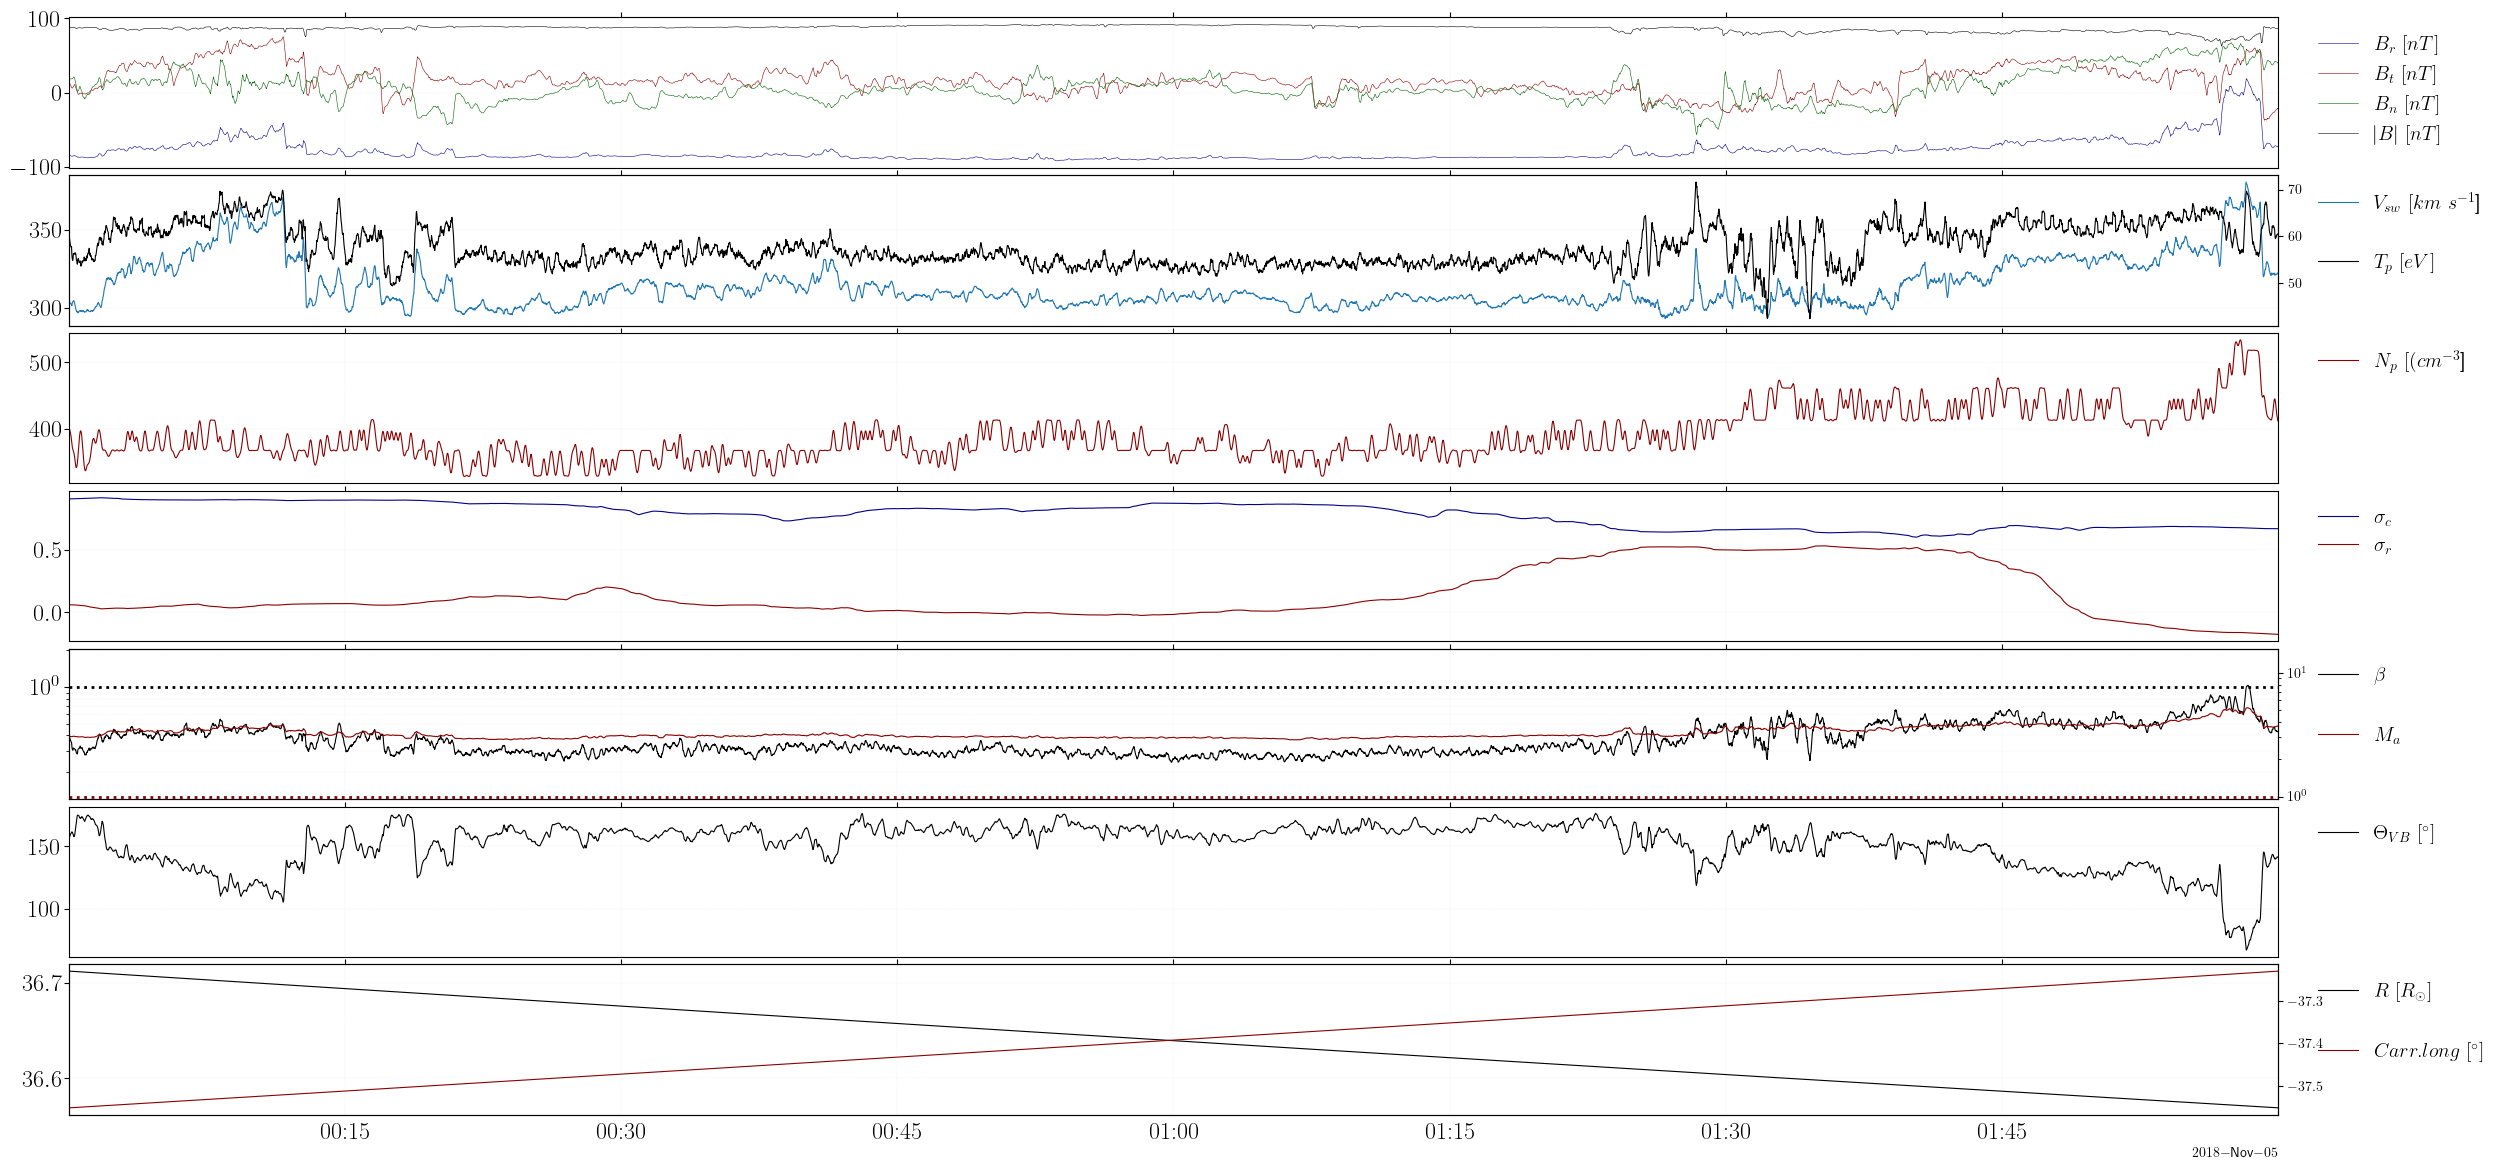

In [6]:
# user defined parameters
w                 = '10s'
sc                = 'PSP'
label_size        = 21                                    # labels etc

n_subplots        = 7                                     # number os subplots
my_dir            = USER_PATHS["save_destination"] #
format_2_return   = "%Y_%m_%d"                            # Format to save figures


figs.visualize_downloaded_intervals(
                                  sc                         ,
                                  fin['Par']['V_resampled'].rolling(w, center=True).mean() ,
                                  fin['Mag']['B_resampled'].rolling(w, center=True).mean() ,
                                  sig.rolling(w, center=True).mean()   ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  numb_subplots    = n_subplots
                                 )



# Estimate Power Spectral Density (PSD) of the magnetic field.
 - When using high resolution data, 'smoothing_function' is going to be slow!

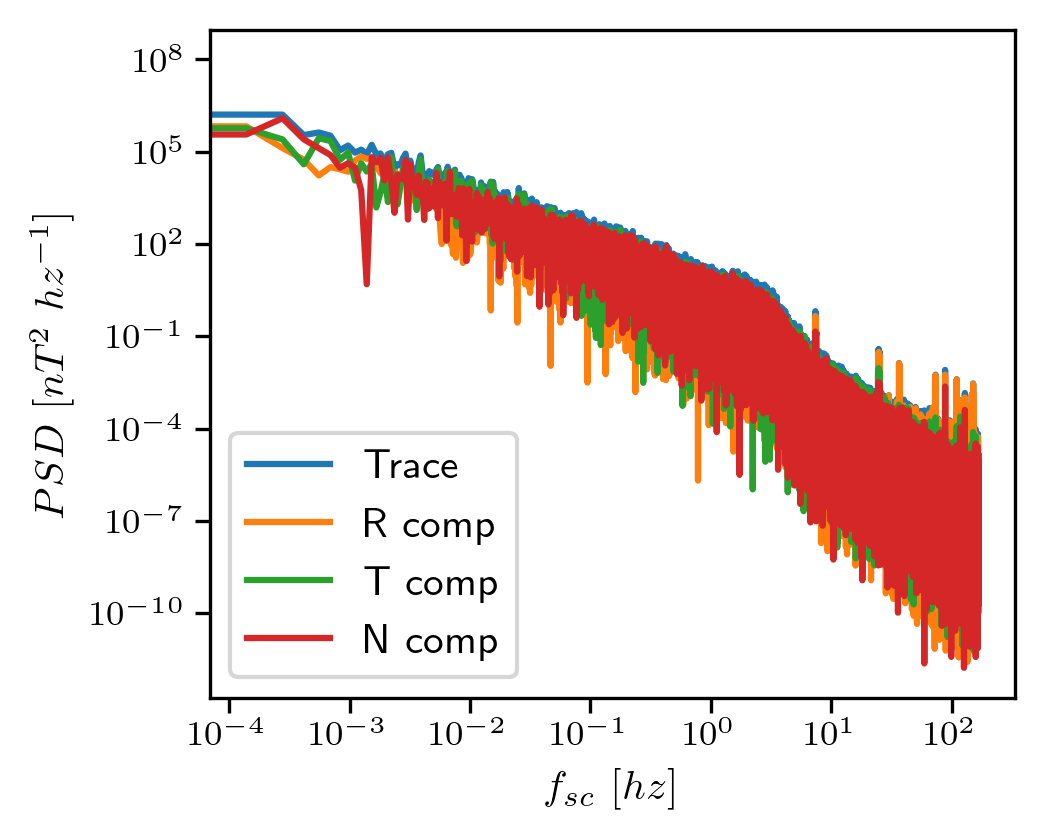

In [7]:
fig, ax =figs.initializeFigure(r'$PSD ~[nT^{2}~ hz^{-1}]$', r'$f_{sc} ~[hz]$')


plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig'], label ='Trace')
plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_R'], label ='R comp')
plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_T'], label ='T comp')
plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_N'], label ='N comp')

plt.legend()

# Smooth and fit the PSD

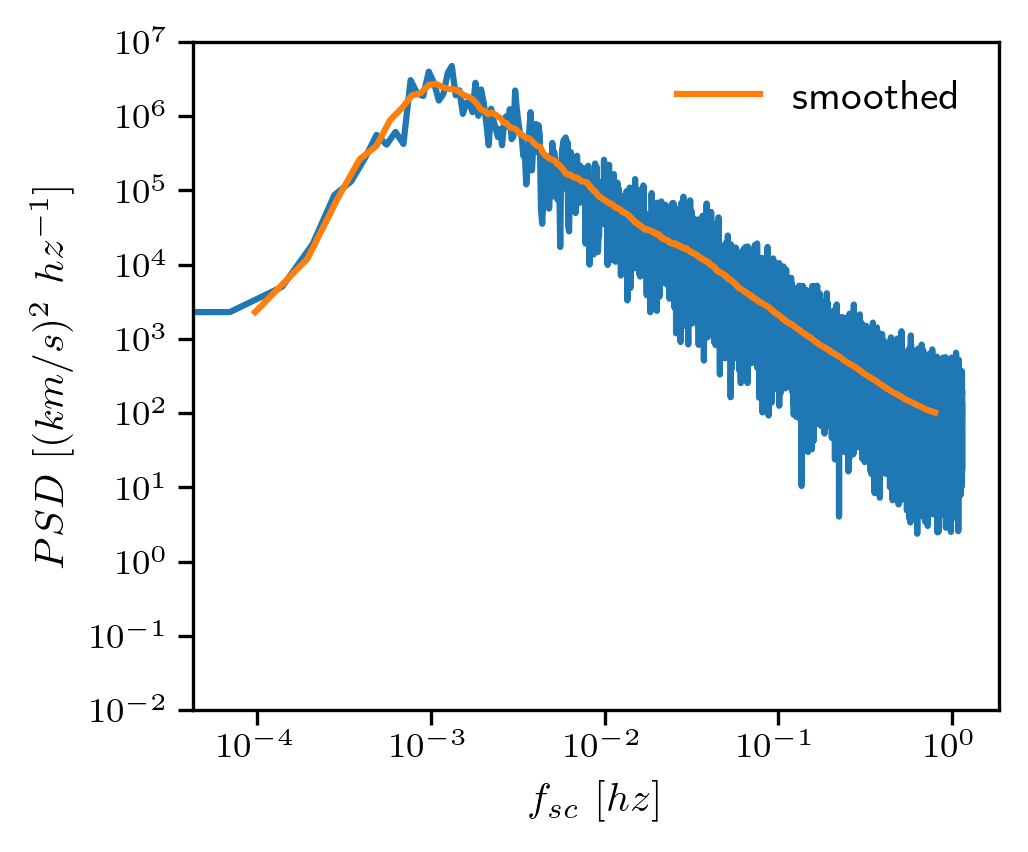

In [66]:
# Define fit range
x0, xf = 8e-4, 1e-2


# Initialize figure
fig, ax =figs.initializeFigure(r'$PSD ~[(km/s)^{2}~ hz^{-1}]$', r'$f_{sc} ~[hz]$')


# Smooth the PSD using a window of 2
sm = func.smoothing_function(fin['Par']['dict_psd']['f_zpm'], fin['Par']['dict_psd']['psd_v'])



# Estimate fit 
fit, s, e, x, y = func.find_fit(fin['Par']['dict_psd']['f_zpm'], fin['Par']['dict_psd']['psd_v'], x0, xf)


# Add legend
lab_name =r'$\propto f^{ {%.2f}   }$'  %(round(fit[1],2))


# Plot everything
plt.loglog(fin['Par']['dict_psd']['f_zpm'], fin['Par']['dict_psd']['psd_v'])
plt.loglog(sm[0], sm[1], label ='smoothed')
#plt.loglog(x[s:e],5*fit[2], 'k-.', lw=1.2, ls='-',label=lab_name) 
plt.ylim([1e-2, 1e7])


plt.legend(frameon=0)


In [67]:
import numpy as np

dt = func.find_cadence(sig)
# dt = 1/fs in seconds
freqs, Pv = turb.TracePSD(sig["dv_r"],  sig["dv_t"],  sig["dv_n"],  dt, remove_mean=0)
_,     Pb = turb.TracePSD(sig["dva_r"], sig["dva_t"], sig["dva_n"], dt, remove_mean=0)

Er = 0.5 * (Pv - Pb)   # signed residual-energy spectrum (units: (velocity)^2/Hz)


In [68]:
dt = gen['Resolution_part']/1000

In [69]:
1/np.nanmedian(np.diff(fin['Par']['dict_psd']['f_zpm']))

np.float64(14399.771999997574)

(1.0, 10000000.0)

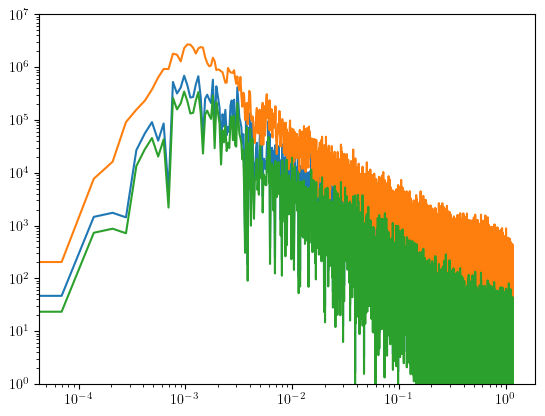

In [70]:
plt.loglog(fin['Par']['dict_psd']['f_zpm'], np.abs(fin['Par']['dict_psd']['psd_v']-fin['Par']['dict_psd']['psd_b'])/4, label =r'$V_a$')
plt.loglog(fin['Par']['dict_psd']['f_zpm'], fin['Par']['dict_psd']['psd_zm'], label =r'$V$')
plt.loglog(fin['Par']['dict_psd']['f_zpm'], np.abs(Er)/4)
plt.ylim([1e-0, 1e7])

# Plot normalized cross helicity and residual energy spectrum

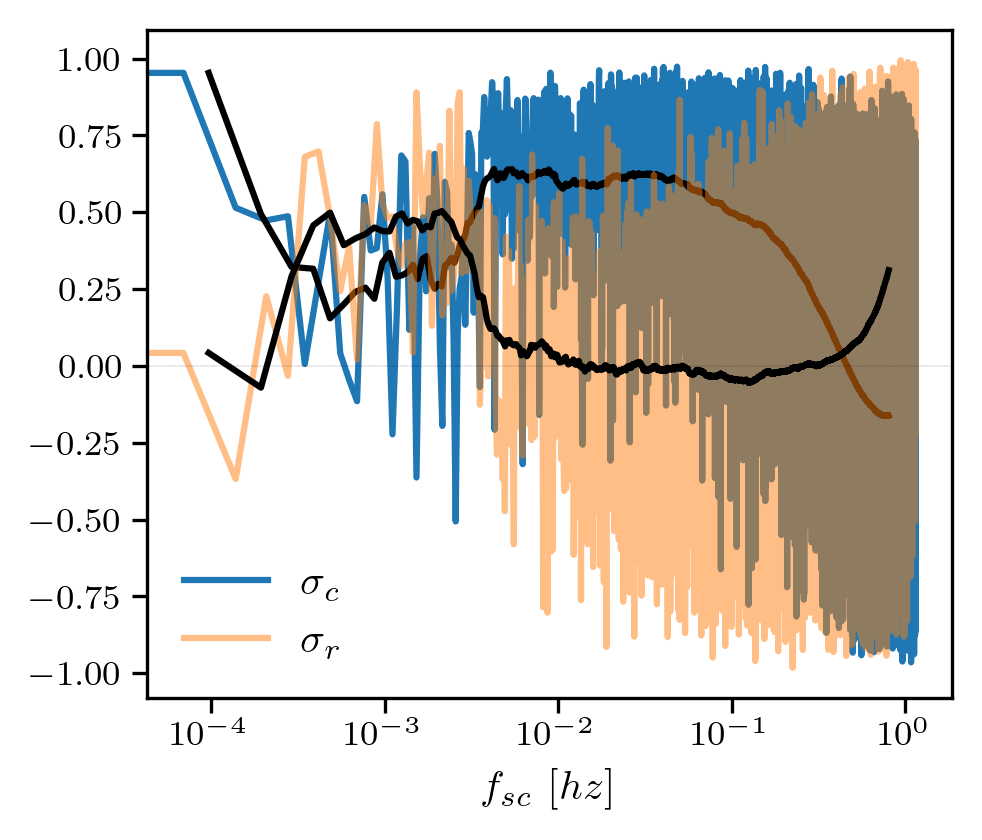

In [71]:
fig, ax =figs.initializeFigure(r'', r'$f_{sc} ~[hz]$')


zp = fin['Par']['dict_psd']['psd_zp']
zm = fin['Par']['dict_psd']['psd_zm']

va = fin['Par']['dict_psd']['psd_b']
v  = fin['Par']['dict_psd']['psd_v']

plt.yscale('linear')
plt.semilogx(fin['Par']['dict_psd']['f_zpm'], (zp-zm)/(zp+zm), label =r'$\sigma_c$')
sm = func.smoothing_function(fin['Par']['dict_psd']['f_zpm'], (zp-zm)/(zp+zm))
plt.semilogx(sm[0], sm[1],c='k')

plt.semilogx(fin['Par']['dict_psd']['f_zpm'], (v-va)/(v+va), alpha=0.5,  label =r'$\sigma_r$')
sm = func.smoothing_function(fin['Par']['dict_psd']['f_zpm'], (v-va)/(v+va))
plt.semilogx(sm[0], sm[1],c='k')

# Smooth the PSD using a window of 2

#plt.axvline(fin['Par']['dict_psd']['f_zpm'][ind[0]])
plt.axhline(y=0, c='k', lw=0.1, ls=':')
plt.legend(frameon=0)

#  Estimate PVI Timeseries

19-Jan-26 07:56:09: /Users/turbulator/miniforge3/envs/mhdturbpy/lib/python3.12/site-packages/joblib/_utils.py:37: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # <number>

19-Jan-26 07:56:09: /Users/turbulator/miniforge3/envs/mhdturbpy/lib/python3.12/site-packages/joblib/_utils.py:38: DeprecationWarning: Attribute n is deprecated and will be removed in Python 3.14; use value instead
  return node.n



(0.0, 0.05500000000000001)

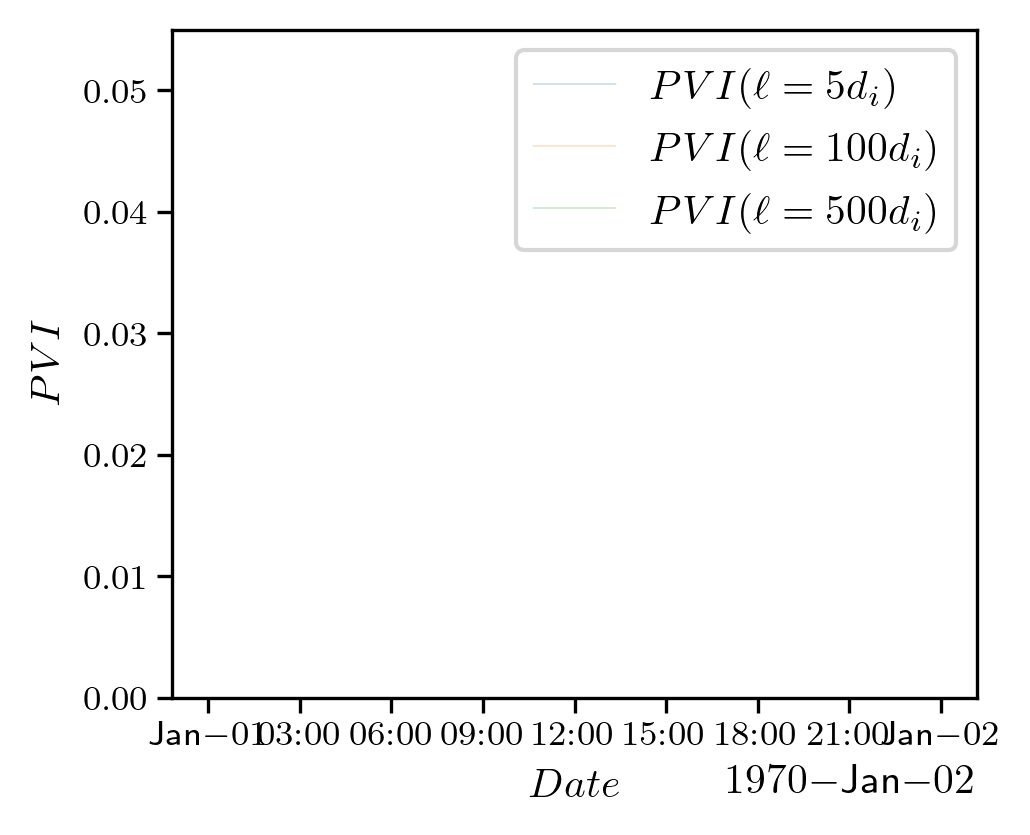

In [72]:
# User defined parameters
hours                  = 4                             # Averaging window in denominator (Hours)
hmany                  = [5, 100, 500]               # Estimate PVI timeseries using a lag of \ell =hmany*di
taus                   = None
B_df                   = fin['Mag']['B_resampled']
V_df                   = fin['Par']['V_resampled']

#
di                     = fin['Par']['di_mean']       # Mean value of ion inertial length for the interval
Vsw                    = fin['Par']['Vsw_mean']      # Mean value of Solar wind speed  for the interval

# Define figure labels
ylabel, xlabel         = r'$PVI$',  r"$Date$"
inset_f_size           = 7



# Run function
PVI_ts                 =turb.estimate_PVI(B_df,
                                           hmany, 
                                           taus,
                                           di,
                                           Vsw,
                                           hours,
                                           PVI_vec_or_mod='vec'
                                          )



# init Figure
fig, ax  = figs.initializeFigure(ylabel, xlabel, '1col')

for kk in range(len(hmany)):
    ax.plot(PVI_ts['PVI_'+str(hmany[kk])], ls='-', ms=0, lw=0.1, label =r'$PVI(\ell= {%d} d_{i})$'%(hmany[kk]))
    
    # # Estimate PDF of PVI
    # res =func.pdf(PVI_ts['PVI_'+str(hmany[kk])].dropna().values, nbins, loglog, density)
    # ax2.semilogy(res[0], res[1], ls='-', ms=0, lw=0.1,c ='C'+str(kk))
    # ax2.set_ylabel(r'$p(PVI)$')
    # ax2.set_ylabel(r'$PVI$')
    


ax.legend(loc=0, )
ax.set_ylim([0,None])


# Superposed epoch analysis
- For more information check (https://github.com/nsioulas/SEA)


1


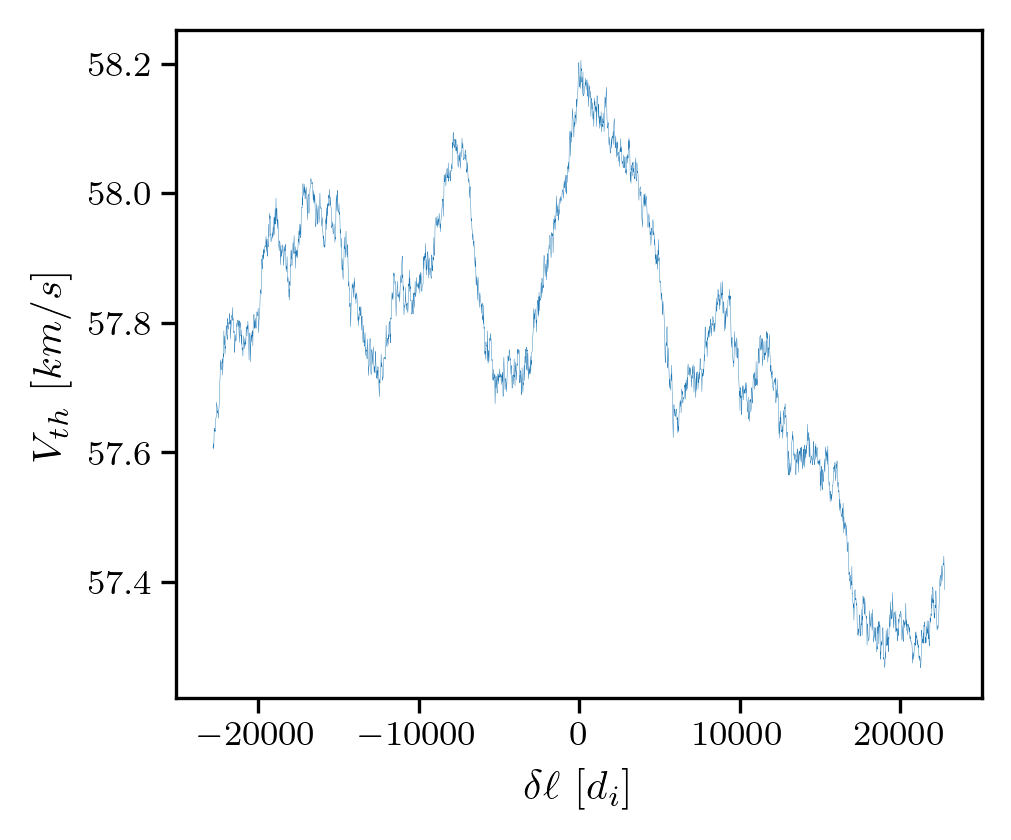

In [61]:
# user defined parameters
time_around        = '1000s'   # Time around identified events
which_one          =  'Vth'    # Parameter to be plotted on y axis
mean_or_median     =  0        # Estimate mean (1) or median (0) of events
resample_rate      =  '800ms'  # Cadence of joined timeseries
which_one_2_plot   = 0 


# you can actually aplly multiple conditions
condit_variables   = ['PVI_500']#, 'sigma_r']
conditions         = [['>=']]#, ['>=','<='] ]
threshold_values   = [[1]]#, [-0.15, 0.1]]


ylabel, xlabel     = r'$V_{th} ~[km/s]$',  r"$\delta \ell ~[d_i]$"


# Merge the two dfs
f_df = PVI_ts.resample(resample_rate ).mean().join(
     V_df.resample(resample_rate ).mean()
)


# run SEA function
results  = SEA(f_df,
              condit_variables,
              threshold_values,
              conditions,
              time_around,
              which_one,
              mean_or_median,
              resample_rate)


# Assign
keys =list(results.keys())
xvals, yvals, y_std, y_std_err_mean = results[keys[which_one_2_plot]]


# convert temporal lag to spatial and normalize with di
di_lag    = Vsw*xvals/di

# init Figure
fig, ax   = figs.initializeFigure(ylabel, xlabel, '1col')

ax.plot(di_lag, yvals, ls='-', ms=0, lw=0.1)
    

In [20]:
import numpy as np
from scipy.signal import stft, istft


def _interp_nans_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    n = x.size
    if n == 0:
        return x
    ok = np.isfinite(x)
    if ok.all():
        return x
    if ok.sum() < 2:
        return np.zeros_like(x)
    idx = np.arange(n)
    y = x.copy()
    y[~ok] = np.interp(idx[~ok], idx[ok], x[ok])
    return y


def remove_wheel_noise(
    x: np.ndarray,
    fs: float,
    *,
    # -----------------------
    # STFT geometry
    # -----------------------
    freq_min: float = 4.0,
    stft_nperseg: int = 2048,
    stft_overlap: float = 0.75,
    stft_seconds: float | None = 8.0,

    # -----------------------
    # Mode
    # -----------------------
    detect_mode: str = "harmonic_track",
    thresh_db: float = 6.0,

    # -----------------------
    # Harmonic comb prior
    # -----------------------
    line_base_hz: float = 8.0,
    line_max_hz: float | None = None,
    fixed_lines_hz: tuple[float, ...] | None = None,

    # -----------------------
    # Drift tracking + baseline estimation
    # -----------------------
    line_search_half_width_hz: float = 1.0,
    remove_half_width_hz: float = 0.35,
    baseline_guard_hz: float = 0.35,
    baseline_width_hz: float = 1.5,
    baseline_q: float = 0.50,              # IMPORTANT: default back to median to avoid low-bias
    baseline_mode: str = "log_interp_lr",  # "log_interp_lr" (recommended) or "pooled"
    min_active_time_bins: int = 1,

    # -----------------------
    # Suppression policy
    # -----------------------
    atten_db: float = 40.0,                # absolute min gain
    per_bin_clip: bool = True,             # clip each bin (kills wings)
    target_db_above_base: float = 0.5,     # allow small headroom to avoid notches
    smooth_freq_taper: bool = False,       # tapering can leave wings; default OFF

    # -----------------------
    # Safety / raising threshold
    # -----------------------
    max_mask_frac: float = 0.08,
    auto_raise_thresh: bool = True,
    raise_step_db: float = 2.0,
    raise_max_iter: int = 4,

    # -----------------------
    # Backward-compat / ignored keys
    # -----------------------
    percentile_q: float = 99.5,
    kernel: int = 101,
    whiten_exp: float = 0.0,
    merge_hz: float = 0.20,
    max_lines: int = 2000,
    fallback_top_k: int = 80,
    fallback_min_maxscore_db: float = 2.0,
    dilate_time_bins: int = 0,
    mad_mult=None,

    # -----------------------
    # Debug
    # -----------------------
    return_debug: bool = False,
    **_ignored,
):
    """
    Harmonic line tracking + suppression for SolO-like clock-line comb.

    Fixes the main oversubtraction bug:
      - baseline estimated from left/right sidebands separately
      - baseline at line center computed by log interpolation (slope-consistent)
      - clipping target set to baseline + small headroom (target_db_above_base)
      - drift handled via per-time peak tracking within line_search_half_width_hz

    Recommended:
      detect_mode="harmonic_track"
      baseline_mode="log_interp_lr"
      per_bin_clip=True
      target_db_above_base ~ 0.3-1.0 dB
    """

    x = np.asarray(x, float)

    if x.ndim == 1:
        xin = _interp_nans_1d(x)
        n = xin.size
        nchan = 1
    elif x.ndim == 2 and x.shape[0] > 0 and x.shape[1] in (2, 3):
        xin = np.stack([_interp_nans_1d(x[:, j]) for j in range(x.shape[1])], axis=1)
        n = xin.shape[0]
        nchan = xin.shape[1]
    else:
        xin = _interp_nans_1d(x.ravel())
        n = xin.size
        nchan = 1

    if n < 64 or (not np.isfinite(fs)) or fs <= 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs) if np.isfinite(fs) else np.nan,
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": 0,
            "noverlap": 0,
            "df_hz": np.nan,
        }
        return (xin, dbg) if return_debug else xin

    fs = float(fs)
    nyq = 0.5 * fs

    if stft_seconds is not None and float(stft_seconds) > 0:
        nperseg = int(round(fs * float(stft_seconds)))
    else:
        nperseg = int(stft_nperseg)

    nperseg = int(min(max(256, nperseg), n))

    noverlap = int(round(nperseg * float(stft_overlap)))
    noverlap = min(max(0, noverlap), nperseg - 1)

    def _stft_1d(sig: np.ndarray):
        return stft(
            sig,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            boundary="zeros",
            padded=True,
        )

    if nchan == 1:
        f, tt, Z = _stft_1d(xin)
        Z_list = [Z]
    else:
        f, tt, Z0 = _stft_1d(xin[:, 0])
        Z_list = [Z0]
        for j in range(1, nchan):
            f2, tt2, Zj = _stft_1d(xin[:, j])
            if f2.shape != f.shape or tt2.shape != tt.shape:
                dbg = {
                    "mask_frac": 0.0,
                    "nCand": 0,
                    "max_score_db": np.nan,
                    "fs": float(fs),
                    "thresh_db_used": float(thresh_db),
                    "detect_mode": str(detect_mode),
                    "nperseg": int(nperseg),
                    "noverlap": int(noverlap),
                    "df_hz": np.nan,
                }
                return (xin, dbg) if return_debug else xin
            Z_list.append(Zj)

    if f.size < 2 or Z_list[0].size == 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": np.nan,
        }
        return (xin, dbg) if return_debug else xin

    df = float(f[1] - f[0])
    valid_f = (f >= float(freq_min)) & (f < nyq)

    if not np.any(valid_f):
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
        }
        return (xin, dbg) if return_debug else xin

    eps = 1e-30
    detect_mode_eff = str(detect_mode).strip().lower()
    baseline_mode_eff = str(baseline_mode).strip().lower()

    def _istft_1d(Zc: np.ndarray) -> np.ndarray:
        _, y = istft(
            Zc,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            boundary=True,
        )
        if y.size > n:
            y = y[:n]
        elif y.size < n:
            y = np.pad(y, (0, n - y.size))
        return y

    def _time_min_run(active: np.ndarray, minlen: int) -> np.ndarray:
        if minlen <= 1:
            return active.astype(bool, copy=False)
        a = active.astype(bool, copy=False)
        ntt = a.size
        if ntt == 0:
            return a
        out = np.zeros_like(a, dtype=bool)
        i = 0
        while i < ntt:
            if not a[i]:
                i += 1
                continue
            j = i + 1
            while j < ntt and a[j]:
                j += 1
            if (j - i) >= minlen:
                out[i:j] = True
            i = j
        return out

    gain_floor = 10.0 ** (-float(atten_db) / 20.0)
    target_gain_factor = 10.0 ** (float(target_db_above_base) / 20.0)

    def _freq_taper(fgrid: np.ndarray, fc: float, halfw: float) -> np.ndarray:
        if (not smooth_freq_taper) or halfw <= 0:
            return np.ones_like(fgrid, dtype=float)
        sigma = max(halfw / 2.0, df)
        d = np.abs(fgrid - fc)
        w = np.exp(-0.5 * (d / sigma) ** 2)
        w = w / (np.max(w) + 1e-30)
        return w

    if detect_mode_eff != "harmonic_track":
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
        }
        return (xin, dbg) if return_debug else xin

    fmax = float(line_max_hz) if (line_max_hz is not None and np.isfinite(line_max_hz)) else float(nyq - df)
    fmax = min(fmax, float(nyq - df))

    line_centers = []
    base = float(line_base_hz)
    if np.isfinite(base) and base > 0:
        kmax = int(np.floor(fmax / base))
        for k in range(1, max(1, kmax + 1)):
            fc = float(k) * base
            if fc >= float(freq_min) and fc < float(nyq):
                line_centers.append(fc)

    if fixed_lines_hz is not None:
        for fc in fixed_lines_hz:
            if fc is None or (not np.isfinite(fc)):
                continue
            fc = float(fc)
            if fc >= float(freq_min) and fc < float(nyq):
                line_centers.append(fc)

    line_centers = sorted(set([float(fc) for fc in line_centers]))

    if len(line_centers) == 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
            "n_lines_total": 0,
            "n_lines_used": 0,
        }
        return (xin, dbg) if return_debug else xin

    Zc_list = [Zk.copy() for Zk in Z_list]
    nt = Zc_list[0].shape[1]
    total_valid_bins = int(np.sum(valid_f) * nt)

    thr = float(thresh_db)

    def _baseline_from_sidebands(P_left: float, P_right: float) -> float:
        if np.isfinite(P_left) and P_left > 0 and np.isfinite(P_right) and P_right > 0:
            if baseline_mode_eff == "log_interp_lr":
                return float(10.0 ** (0.5 * (np.log10(P_left) + np.log10(P_right))))
            return float(np.median([P_left, P_right]))
        if np.isfinite(P_left) and P_left > 0:
            return float(P_left)
        if np.isfinite(P_right) and P_right > 0:
            return float(P_right)
        return np.nan

    def _apply_once(thr_db: float):
        total_modified_bins = 0
        max_score_db_seen = -np.inf
        n_lines_used = 0

        for fc0 in line_centers:
            idx_search = np.where((np.abs(f - fc0) <= float(line_search_half_width_hz)) & valid_f)[0]
            if idx_search.size == 0:
                continue

            Zref = Zc_list[0]
            Pref = np.abs(Zref[idx_search, :]) ** 2
            ip_local = np.argmax(Pref, axis=0)
            ip = idx_search[ip_local]

            active = np.zeros(nt, dtype=bool)

            for it in range(nt):
                ic = int(ip[it])
                fc_hat = float(f[ic])

                idx_line = np.where((np.abs(f - fc_hat) <= float(remove_half_width_hz)) & valid_f)[0]
                if idx_line.size == 0:
                    continue

                lo1 = float(remove_half_width_hz) + float(baseline_guard_hz)
                lo2 = lo1 + float(baseline_width_hz)

                idx_left = np.where((f >= (fc_hat - lo2)) & (f <= (fc_hat - lo1)) & valid_f)[0]
                idx_right = np.where((f >= (fc_hat + lo1)) & (f <= (fc_hat + lo2)) & valid_f)[0]
                if idx_left.size < 3 and idx_right.size < 3:
                    continue

                P_line = float(np.max(np.abs(Zref[idx_line, it]) ** 2))
                P_left = float(np.quantile(np.abs(Zref[idx_left, it]) ** 2, float(baseline_q))) if idx_left.size > 0 else np.nan
                P_right = float(np.quantile(np.abs(Zref[idx_right, it]) ** 2, float(baseline_q))) if idx_right.size > 0 else np.nan
                P_base = _baseline_from_sidebands(P_left, P_right)

                if not np.isfinite(P_base) or P_base <= 0:
                    continue

                score_db = 10.0 * np.log10((P_line + eps) / (P_base + eps))
                max_score_db_seen = max(max_score_db_seen, score_db)

                if score_db > float(thr_db):
                    active[it] = True

            active = _time_min_run(active, int(min_active_time_bins))
            if not np.any(active):
                continue

            n_lines_used += 1
            t_idx = np.where(active)[0]

            for it in t_idx:
                ic = int(ip[it])
                fc_hat = float(f[ic])

                idx_line = np.where((np.abs(f - fc_hat) <= float(remove_half_width_hz)) & valid_f)[0]
                if idx_line.size == 0:
                    continue

                lo1 = float(remove_half_width_hz) + float(baseline_guard_hz)
                lo2 = lo1 + float(baseline_width_hz)

                idx_left = np.where((f >= (fc_hat - lo2)) & (f <= (fc_hat - lo1)) & valid_f)[0]
                idx_right = np.where((f >= (fc_hat + lo1)) & (f <= (fc_hat + lo2)) & valid_f)[0]
                if idx_left.size < 3 and idx_right.size < 3:
                    continue

                w = _freq_taper(f[idx_line], fc_hat, float(remove_half_width_hz))

                for j in range(nchan):
                    Zj = Zc_list[j]

                    P_left = float(np.quantile(np.abs(Zj[idx_left, it]) ** 2, float(baseline_q))) if idx_left.size > 0 else np.nan
                    P_right = float(np.quantile(np.abs(Zj[idx_right, it]) ** 2, float(baseline_q))) if idx_right.size > 0 else np.nan
                    P_base = _baseline_from_sidebands(P_left, P_right)

                    if not np.isfinite(P_base) or P_base <= 0:
                        continue

                    A_target = float(np.sqrt(P_base + eps)) * float(target_gain_factor)

                    A_line = np.abs(Zj[idx_line, it])
                    if A_line.size == 0:
                        continue

                    if per_bin_clip:
                        g_bins = A_target / (A_line + eps)
                        g_bins = np.minimum(1.0, g_bins)
                        g_bins = np.maximum(gain_floor, g_bins)
                        g_vec = 1.0 - w * (1.0 - g_bins)
                        Zj[idx_line, it] *= g_vec
                    else:
                        P_line = float(np.max(A_line ** 2))
                        if P_line <= 0:
                            continue
                        g_target = float(A_target / (np.sqrt(P_line + eps)))
                        g_target = min(1.0, max(gain_floor, g_target))
                        g_vec = 1.0 - w * (1.0 - g_target)
                        Zj[idx_line, it] *= g_vec

                total_modified_bins += int(idx_line.size)

        if not np.isfinite(max_score_db_seen):
            max_score_db_seen = np.nan

        return total_modified_bins, float(max_score_db_seen), int(n_lines_used)

    total_modified_bins, max_score_db_seen, n_lines_used = _apply_once(thr)

    if auto_raise_thresh and total_valid_bins > 0:
        for _ in range(int(raise_max_iter)):
            frac = float(total_modified_bins) / float(total_valid_bins)
            if frac <= float(max_mask_frac):
                break
            thr += float(raise_step_db)
            total_modified_bins, max_score_db_seen, n_lines_used = _apply_once(thr)

    if nchan == 1:
        y_out = _istft_1d(Zc_list[0])
    else:
        cols = []
        for j in range(nchan):
            cols.append(_istft_1d(Zc_list[j]))
        y_out = np.stack(cols, axis=1)

    mask_frac = 0.0
    if total_valid_bins > 0:
        mask_frac = float(total_modified_bins) / float(total_valid_bins)

    dbg = {
        "mask_frac": float(mask_frac),
        "nCand": int(n_lines_used),
        "max_score_db": float(max_score_db_seen) if np.isfinite(max_score_db_seen) else np.nan,
        "fs": float(fs),
        "thresh_db_used": float(thr),
        "detect_mode": str(detect_mode),
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "df_hz": float(df),
        "freq_min": float(freq_min),
        "atten_db": float(atten_db),
        "per_bin_clip": bool(per_bin_clip),
        "target_db_above_base": float(target_db_above_base),
        "baseline_q": float(baseline_q),
        "baseline_mode": str(baseline_mode),
        "line_base_hz": float(line_base_hz),
        "line_max_hz": float(line_max_hz) if (line_max_hz is not None and np.isfinite(line_max_hz)) else None,
        "line_search_half_width_hz": float(line_search_half_width_hz),
        "remove_half_width_hz": float(remove_half_width_hz),
        "baseline_guard_hz": float(baseline_guard_hz),
        "baseline_width_hz": float(baseline_width_hz),
        "n_lines_total": int(len(line_centers)),
        "n_lines_used": int(n_lines_used),
    }

    return (y_out, dbg) if return_debug else y_out


In [15]:
which_comp = 'Br'

Selected segment: 2018-11-05 00:00:00.810000 -> 2018-11-05 01:59:59.568000 | N = 2399587
Estimated cadence: dt_med = 3.000000e-03 s  =>  fs = 333.333333 Hz

DEBUG SUMMARY
  atten_db: 40.0
  baseline_guard_hz: 0.35
  baseline_mode: log_interp_lr
  baseline_q: 0.5
  baseline_width_hz: 1.5
  detect_mode: harmonic_track
  df_hz: 0.1249843769528809
  freq_min: 8.0
  fs: 333.3333333333333
  line_base_hz: 8.0
  line_max_hz: 120.0
  line_search_half_width_hz: 1.25
  mask_frac: 0.013376450117152322
  max_score_db: 26.41761722499114
  nCand: 15
  n_lines_total: 15
  n_lines_used: 15
  noverlap: 2000
  nperseg: 2667
  per_bin_clip: True
  remove_half_width_hz: 0.55
  target_db_above_base: 0.5
  thresh_db_used: 8.0


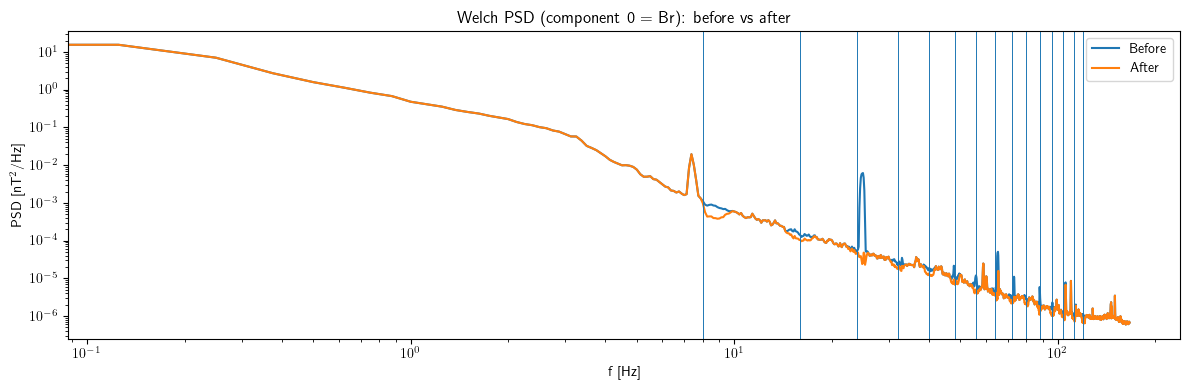

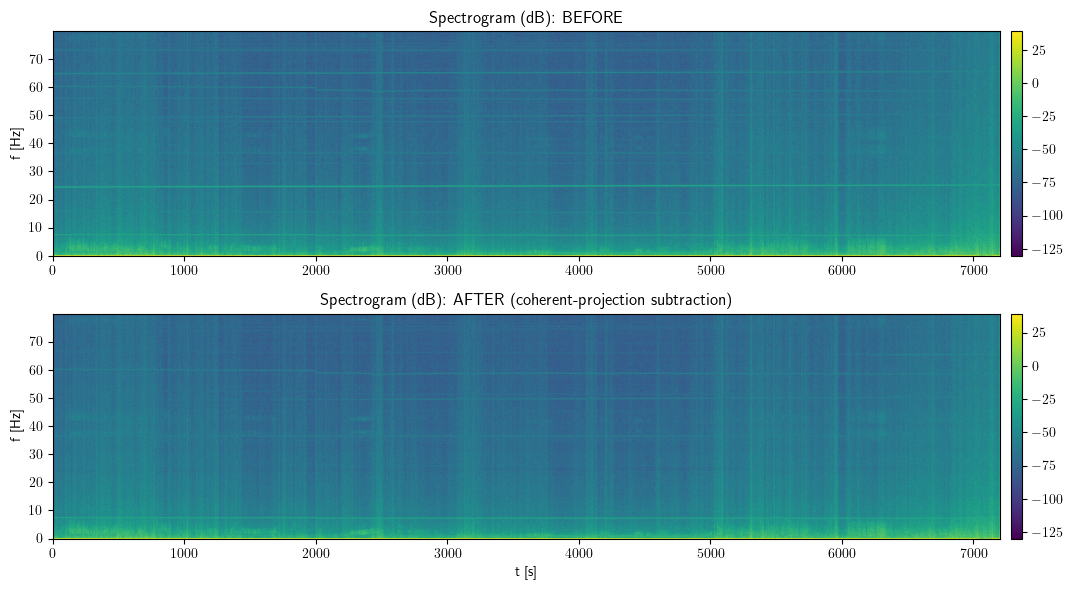

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, stft


# ============================================================
# 0) Select a REALISTIC interval to test (keeps memory/plots sane)
#    Adjust these two lines if you want a different segment.
# ============================================================
Bdf = fin["Mag"]["B_resampled"]

t_start = Bdf.index[0]
t_stop  = Bdf.index[-1]

Bseg = Bdf.loc[t_start:t_stop, ["Br", "Bt", "Bn"]].copy()
print("Selected segment:", Bseg.index[0], "->", Bseg.index[-1], "| N =", len(Bseg))


# ============================================================
# 1) Infer sampling rate from the index
# ============================================================
t_ns = Bseg.index.view("int64")
dt = np.diff(t_ns).astype(np.float64) * 1e-9
dt_med = np.nanmedian(dt)
fs = 1.0 / dt_med

print(f"Estimated cadence: dt_med = {dt_med:.6e} s  =>  fs = {fs:.6f} Hz")


# ============================================================
# 2) Clean using the NEW coherent-projection subtraction version
#    (remove_wheel_noise must be the NEW function already defined)
# ============================================================
B = Bseg.to_numpy(dtype=float)

Bout, dbg = remove_wheel_noise(
    B,
    fs,
    stft_seconds=8.0,
    stft_overlap=0.75,
    freq_min=8.0,
    line_base_hz=8.0,
    line_max_hz=min(120.0, 0.5 * fs - 1.0),
    line_search_half_width_hz=1.25,
    remove_half_width_hz=0.55,
    baseline_guard_hz=0.35,
    baseline_width_hz=1.5,
    baseline_q=0.50,
    baseline_mode="log_interp_lr",
    thresh_db=6.0,
    target_db_above_base=0.5,
    replace_only_if_above=True,
    inpaint_full_window=False,
    blend_edges=True,
    return_debug=True,
)


print("\nDEBUG SUMMARY")
for k in sorted(dbg.keys()):
    print(f"  {k}: {dbg[k]}")

Bclean = pd.DataFrame(Bout, index=Bseg.index, columns=["Br", "Bt", "Bn"])


# ============================================================
# 3) PSD before/after (Welch) for component 0 = Br
# ============================================================
nper_psd = int(round(8.0 * fs))
nper_psd = max(256, min(nper_psd, len(Bseg)))
nover_psd = int(round(0.5 * nper_psd))

f_psd, P_before = welch(
    Bseg[which_comp].to_numpy(dtype=float),
    fs=fs,
    nperseg=nper_psd,
    noverlap=nover_psd,
    window="hann",
    detrend="constant",
    scaling="density",
)
_, P_after = welch(
    Bclean[which_comp].to_numpy(dtype=float),
    fs=fs,
    nperseg=nper_psd,
    noverlap=nover_psd,
    window="hann",
    detrend="constant",
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.loglog(f_psd, P_before, label="Before")
plt.loglog(f_psd, P_after,  label="After")
plt.xlabel("f [Hz]")
plt.ylabel("PSD [nT$^2$/Hz]")
plt.title("Welch PSD (component 0 = Br): before vs after")

fmax_lines = min(120.0, 0.5 * fs - 1.0)
for k in range(1, int(np.floor(fmax_lines / 8.0)) + 1):
    plt.axvline(8.0 * k, linewidth=0.7)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4) Spectrogram before/after (STFT dB) for component 0 = Br
# ============================================================
nper_tf = int(round(8.0 * fs))
nper_tf = max(256, min(nper_tf, len(Bseg)))
nover_tf = int(round(0.75 * nper_tf))

f_sp, tt_sp, Zb = stft(
    Bseg[which_comp].to_numpy(dtype=float),
    fs=fs,
    window="hann",
    nperseg=nper_tf,
    noverlap=nover_tf,
    boundary="zeros",
    padded=True,
)
_, _, Za = stft(
    Bclean[which_comp].to_numpy(dtype=float),
    fs=fs,
    window="hann",
    nperseg=nper_tf,
    noverlap=nover_tf,
    boundary="zeros",
    padded=True,
)

Sb_db = 10.0 * np.log10(np.maximum(np.abs(Zb) ** 2, 1e-30))
Sa_db = 10.0 * np.log10(np.maximum(np.abs(Za) ** 2, 1e-30))

fmax_plot = min(80.0, 0.5 * fs - 1.0)
keep_f = f_sp <= fmax_plot

plt.figure(figsize=(12, 6))

ax1 = plt.subplot(2, 1, 1)
im1 = ax1.imshow(
    Sb_db[keep_f, :],
    aspect="auto",
    origin="lower",
    extent=[tt_sp[0], tt_sp[-1], f_sp[keep_f][0], f_sp[keep_f][-1]],
)
ax1.set_ylabel("f [Hz]")
ax1.set_title("Spectrogram (dB): BEFORE")
plt.colorbar(im1, ax=ax1, pad=0.01)

ax2 = plt.subplot(2, 1, 2)
im2 = ax2.imshow(
    Sa_db[keep_f, :],
    aspect="auto",
    origin="lower",
    extent=[tt_sp[0], tt_sp[-1], f_sp[keep_f][0], f_sp[keep_f][-1]],
)
ax2.set_xlabel("t [s]")
ax2.set_ylabel("f [Hz]")
ax2.set_title("Spectrogram (dB): AFTER (coherent-projection subtraction)")
plt.colorbar(im2, ax=ax2, pad=0.01)

plt.tight_layout()
plt.show()


In [11]:
Bdf

,Br,Bt,Bn
datetime,,,
2018-11-05 00:00:00.810,-84.227325,16.593405,19.126392
2018-11-05 00:00:00.813,-84.208984,16.611938,19.097441
2018-11-05 00:00:00.816,-84.195953,16.634470,19.083488
2018-11-05 00:00:00.819,-84.188377,16.663757,19.062447
2018-11-05 00:00:00.822,-84.192673,16.683706,19.061573
...,...,...,...
2018-11-05 01:59:59.556,-71.935242,-23.158979,39.074310
2018-11-05 01:59:59.559,-71.917595,-23.167715,38.960178
2018-11-05 01:59:59.562,-71.954292,-23.264566,38.686272


In [9]:
import numpy as np
from scipy.signal import stft, istft


def _interp_nans_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    n = x.size
    if n == 0:
        return x
    ok = np.isfinite(x)
    if ok.all():
        return x
    if ok.sum() < 2:
        return np.zeros_like(x)
    idx = np.arange(n)
    y = x.copy()
    y[~ok] = np.interp(idx[~ok], idx[ok], x[ok])
    return y


def remove_wheel_noise(
    x: np.ndarray,
    fs: float,
    *,
    # -----------------------
    # STFT geometry
    # -----------------------
    freq_min: float = 8.0,
    stft_nperseg: int = 2048,
    stft_overlap: float = 0.75,
    stft_seconds: float | None = 8.0,

    # -----------------------
    # Mode
    # -----------------------
    detect_mode: str = "harmonic_track",

    # -----------------------
    # Harmonic comb prior
    # -----------------------
    line_base_hz: float = 8.0,
    line_max_hz: float | None = None,
    fixed_lines_hz: tuple[float, ...] | None = None,

    # -----------------------
    # Drift tracking
    # -----------------------
    line_search_half_width_hz: float = 1.25,
    remove_half_width_hz: float = 0.45,

    # -----------------------
    # Baseline sidebands (for detection + shrink-to-baseline)
    # -----------------------
    baseline_guard_hz: float = 0.35,
    baseline_width_hz: float = 1.5,
    baseline_q: float = 0.50,
    baseline_mode: str = "log_interp_lr",   # "log_interp_lr" recommended

    # -----------------------
    # Coherent-projection subtraction (core fix)
    # -----------------------
    coh_thresh: float = 0.55,
    thresh_db: float = 6.0,
    target_db_above_base: float = 0.5,
    max_subtract_frac: float = 0.98,

    # -----------------------
    # Temporal stability gate (FIXED: was missing!)
    # -----------------------
    min_active_time_bins: int = 1,

    # -----------------------
    # Shape model across frequency bins inside the line window
    # -----------------------
    line_shape: str = "gaussian",           # "gaussian" or "flat"
    shape_sigma_frac: float = 0.50,         # sigma = shape_sigma_frac * remove_half_width_hz

    # -----------------------
    # Safety / raising threshold
    # -----------------------
    max_mask_frac: float = 0.08,
    auto_raise_thresh: bool = True,
    raise_step_db: float = 2.0,
    raise_max_iter: int = 4,

    # -----------------------
    # Backward-compat / ignored keys
    # -----------------------
    percentile_q: float = 99.5,
    kernel: int = 301,
    whiten_exp: float = 0.0,
    merge_hz: float = 0.20,
    max_lines: int = 2000,
    fallback_top_k: int = 80,
    fallback_min_maxscore_db: float = 2.0,
    dilate_time_bins: int = 0,
    atten_db: float = 60.0,
    per_bin_clip: bool = False,
    baseline_match: bool = True,
    soft_clip_db: float = 0.25,
    smooth_freq_taper: bool = False,
    always_apply: bool = False,
    mad_mult=None,

    # -----------------------
    # Debug
    # -----------------------
    return_debug: bool = False,
    **_ignored,
):
    """
    Coherent-line removal via STFT coherent projection subtraction.

    Removes only the *coherent* component in each harmonic window by projecting the
    complex STFT coefficients onto a simple line shape and subtracting that projection
    down to ~baseline level. This avoids PSD notches caused by magnitude clipping.

    Handles drift by tracking the peak within a search band around each harmonic per time bin.
    """

    x = np.asarray(x, float)

    if x.ndim == 1:
        xin = _interp_nans_1d(x)
        n = xin.size
        nchan = 1
    elif x.ndim == 2 and x.shape[0] > 0 and x.shape[1] in (2, 3):
        xin = np.stack([_interp_nans_1d(x[:, j]) for j in range(x.shape[1])], axis=1)
        n = xin.shape[0]
        nchan = xin.shape[1]
    else:
        xin = _interp_nans_1d(x.ravel())
        n = xin.size
        nchan = 1

    if n < 64 or (not np.isfinite(fs)) or fs <= 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs) if np.isfinite(fs) else np.nan,
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": 0,
            "noverlap": 0,
            "df_hz": np.nan,
        }
        return (xin, dbg) if return_debug else xin

    fs = float(fs)
    nyq = 0.5 * fs

    if stft_seconds is not None and float(stft_seconds) > 0:
        nperseg = int(round(fs * float(stft_seconds)))
    else:
        nperseg = int(stft_nperseg)

    nperseg = int(min(max(256, nperseg), n))

    noverlap = int(round(nperseg * float(stft_overlap)))
    noverlap = min(max(0, noverlap), nperseg - 1)

    def _stft_1d(sig: np.ndarray):
        return stft(
            sig,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            boundary="zeros",
            padded=True,
        )

    if nchan == 1:
        f, tt, Z = _stft_1d(xin)
        Z_list = [Z]
    else:
        f, tt, Z0 = _stft_1d(xin[:, 0])
        Z_list = [Z0]
        for j in range(1, nchan):
            f2, tt2, Zj = _stft_1d(xin[:, j])
            if f2.shape != f.shape or tt2.shape != tt.shape:
                dbg = {
                    "mask_frac": 0.0,
                    "nCand": 0,
                    "max_score_db": np.nan,
                    "fs": float(fs),
                    "thresh_db_used": float(thresh_db),
                    "detect_mode": str(detect_mode),
                    "nperseg": int(nperseg),
                    "noverlap": int(noverlap),
                    "df_hz": np.nan,
                }
                return (xin, dbg) if return_debug else xin
            Z_list.append(Zj)

    if f.size < 2 or Z_list[0].size == 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": np.nan,
        }
        return (xin, dbg) if return_debug else xin

    df = float(f[1] - f[0])
    valid_f = (f >= float(freq_min)) & (f < nyq)

    if not np.any(valid_f):
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
        }
        return (xin, dbg) if return_debug else xin

    eps = 1e-30
    detect_mode_eff = str(detect_mode).strip().lower()
    baseline_mode_eff = str(baseline_mode).strip().lower()

    if detect_mode_eff != "harmonic_track":
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
        }
        return (xin, dbg) if return_debug else xin

    def _istft_1d(Zc: np.ndarray) -> np.ndarray:
        _, y = istft(
            Zc,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            boundary=True,
        )
        if y.size > n:
            y = y[:n]
        elif y.size < n:
            y = np.pad(y, (0, n - y.size))
        return y

    def _time_min_run(active: np.ndarray, minlen: int) -> np.ndarray:
        if minlen <= 1:
            return active.astype(bool, copy=False)
        a = active.astype(bool, copy=False)
        ntt = a.size
        if ntt == 0:
            return a
        out = np.zeros_like(a, dtype=bool)
        i = 0
        while i < ntt:
            if not a[i]:
                i += 1
                continue
            j = i + 1
            while j < ntt and a[j]:
                j += 1
            if (j - i) >= minlen:
                out[i:j] = True
            i = j
        return out

    def _baseline_from_lr(P_left: float, P_right: float) -> float:
        if np.isfinite(P_left) and P_left > 0 and np.isfinite(P_right) and P_right > 0:
            if baseline_mode_eff == "log_interp_lr":
                return float(10.0 ** (0.5 * (np.log10(P_left) + np.log10(P_right))))
            return float(np.median([P_left, P_right]))
        if np.isfinite(P_left) and P_left > 0:
            return float(P_left)
        if np.isfinite(P_right) and P_right > 0:
            return float(P_right)
        return np.nan

    def _line_shape_vec(fc_hat: float, idx_line: np.ndarray) -> np.ndarray:
        if idx_line.size == 0:
            return np.zeros(0, dtype=float)
        ff = f[idx_line]
        if str(line_shape).strip().lower() == "flat":
            return np.ones_like(ff, dtype=float)
        sigma = float(shape_sigma_frac) * float(remove_half_width_hz)
        sigma = max(sigma, df)
        s = np.exp(-0.5 * ((ff - fc_hat) / sigma) ** 2)
        return s

    fmax = float(line_max_hz) if (line_max_hz is not None and np.isfinite(line_max_hz)) else float(nyq - df)
    fmax = min(fmax, float(nyq - df))

    line_centers = []
    base = float(line_base_hz)
    if np.isfinite(base) and base > 0:
        kmax = int(np.floor(fmax / base))
        for k in range(1, max(1, kmax + 1)):
            fc = float(k) * base
            if fc >= float(freq_min) and fc < float(nyq):
                line_centers.append(fc)

    if fixed_lines_hz is not None:
        for fc in fixed_lines_hz:
            if fc is None or (not np.isfinite(fc)):
                continue
            fc = float(fc)
            if fc >= float(freq_min) and fc < float(nyq):
                line_centers.append(fc)

    line_centers = sorted(set([float(fc) for fc in line_centers]))

    if len(line_centers) == 0:
        dbg = {
            "mask_frac": 0.0,
            "nCand": 0,
            "max_score_db": np.nan,
            "fs": float(fs),
            "thresh_db_used": float(thresh_db),
            "detect_mode": str(detect_mode),
            "nperseg": int(nperseg),
            "noverlap": int(noverlap),
            "df_hz": float(df),
            "n_lines_total": 0,
            "n_lines_used": 0,
        }
        return (xin, dbg) if return_debug else xin

    Zc_list = [Zk.copy() for Zk in Z_list]
    nt = Zc_list[0].shape[1]
    total_valid_bins = int(np.sum(valid_f) * nt)

    thr = float(thresh_db)
    target_pow_factor = 10.0 ** (float(target_db_above_base) / 10.0)

    def _apply_once(thr_db: float):
        total_modified_bins = 0
        max_score_db_seen = -np.inf
        n_lines_used = 0

        for fc0 in line_centers:
            idx_search = np.where((np.abs(f - fc0) <= float(line_search_half_width_hz)) & valid_f)[0]
            if idx_search.size == 0:
                continue

            Zref = Zc_list[0]
            Pref = np.abs(Zref[idx_search, :]) ** 2
            ip_local = np.argmax(Pref, axis=0)
            ip = idx_search[ip_local]

            active = np.zeros(nt, dtype=bool)

            for it in range(nt):
                ic = int(ip[it])
                fc_hat = float(f[ic])

                idx_line = np.where((np.abs(f - fc_hat) <= float(remove_half_width_hz)) & valid_f)[0]
                if idx_line.size < 3:
                    continue

                lo1 = float(remove_half_width_hz) + float(baseline_guard_hz)
                lo2 = lo1 + float(baseline_width_hz)

                idx_left = np.where((f >= (fc_hat - lo2)) & (f <= (fc_hat - lo1)) & valid_f)[0]
                idx_right = np.where((f >= (fc_hat + lo1)) & (f <= (fc_hat + lo2)) & valid_f)[0]
                if idx_left.size < 3 and idx_right.size < 3:
                    continue

                Zseg = Zref[idx_line, it]
                s = _line_shape_vec(fc_hat, idx_line)
                denom = float(np.sum(s * s) + eps)
                a = np.sum(s * Zseg) / denom
                pred = a * s

                Pcoh = float(np.mean(np.abs(pred) ** 2))
                frac_coh = float(np.linalg.norm(pred) / (np.linalg.norm(Zseg) + eps))

                P_left = float(np.quantile(np.abs(Zref[idx_left, it]) ** 2, float(baseline_q))) if idx_left.size > 0 else np.nan
                P_right = float(np.quantile(np.abs(Zref[idx_right, it]) ** 2, float(baseline_q))) if idx_right.size > 0 else np.nan
                Pbase = _baseline_from_lr(P_left, P_right)

                if not np.isfinite(Pbase) or Pbase <= 0:
                    continue

                score_db = 10.0 * np.log10((Pcoh + eps) / (Pbase + eps))
                max_score_db_seen = max(max_score_db_seen, score_db)

                if (frac_coh >= float(coh_thresh)) and (score_db >= float(thr_db)):
                    active[it] = True

            active = _time_min_run(active, int(min_active_time_bins))
            if not np.any(active):
                continue

            n_lines_used += 1
            t_idx = np.where(active)[0]

            for it in t_idx:
                ic = int(ip[it])
                fc_hat = float(f[ic])

                idx_line = np.where((np.abs(f - fc_hat) <= float(remove_half_width_hz)) & valid_f)[0]
                if idx_line.size < 3:
                    continue

                lo1 = float(remove_half_width_hz) + float(baseline_guard_hz)
                lo2 = lo1 + float(baseline_width_hz)

                idx_left = np.where((f >= (fc_hat - lo2)) & (f <= (fc_hat - lo1)) & valid_f)[0]
                idx_right = np.where((f >= (fc_hat + lo1)) & (f <= (fc_hat + lo2)) & valid_f)[0]
                if idx_left.size < 3 and idx_right.size < 3:
                    continue

                s = _line_shape_vec(fc_hat, idx_line)
                denom = float(np.sum(s * s) + eps)

                for j in range(nchan):
                    Zj = Zc_list[j]

                    P_left = float(np.quantile(np.abs(Zj[idx_left, it]) ** 2, float(baseline_q))) if idx_left.size > 0 else np.nan
                    P_right = float(np.quantile(np.abs(Zj[idx_right, it]) ** 2, float(baseline_q))) if idx_right.size > 0 else np.nan
                    Pbase = _baseline_from_lr(P_left, P_right)

                    if not np.isfinite(Pbase) or Pbase <= 0:
                        continue

                    Zseg = Zj[idx_line, it]
                    a = np.sum(s * Zseg) / denom
                    pred = a * s

                    Pcoh = float(np.mean(np.abs(pred) ** 2))
                    Ptarget = float(Pbase) * float(target_pow_factor)

                    if (not np.isfinite(Pcoh)) or Pcoh <= 0 or Pcoh <= Ptarget:
                        continue

                    alpha = 1.0 - float(np.sqrt((Ptarget + eps) / (Pcoh + eps)))
                    alpha = float(np.clip(alpha, 0.0, float(max_subtract_frac)))

                    Zj[idx_line, it] = Zseg - alpha * pred

                total_modified_bins += int(idx_line.size)

        if not np.isfinite(max_score_db_seen):
            max_score_db_seen = np.nan

        return int(total_modified_bins), float(max_score_db_seen), int(n_lines_used)

    total_modified_bins, max_score_db_seen, n_lines_used = _apply_once(thr)

    if auto_raise_thresh and total_valid_bins > 0:
        for _ in range(int(raise_max_iter)):
            frac = float(total_modified_bins) / float(total_valid_bins)
            if frac <= float(max_mask_frac):
                break
            thr += float(raise_step_db)
            total_modified_bins, max_score_db_seen, n_lines_used = _apply_once(thr)

    if nchan == 1:
        y_out = _istft_1d(Zc_list[0])
    else:
        cols = []
        for j in range(nchan):
            cols.append(_istft_1d(Zc_list[j]))
        y_out = np.stack(cols, axis=1)

    mask_frac = 0.0
    if total_valid_bins > 0:
        mask_frac = float(total_modified_bins) / float(total_valid_bins)

    dbg = {
        "mask_frac": float(mask_frac),
        "nCand": int(n_lines_used),
        "max_score_db": float(max_score_db_seen) if np.isfinite(max_score_db_seen) else np.nan,
        "fs": float(fs),
        "thresh_db_used": float(thr),
        "detect_mode": str(detect_mode),
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "df_hz": float(df),
        "freq_min": float(freq_min),
        "line_base_hz": float(line_base_hz),
        "line_max_hz": float(line_max_hz) if (line_max_hz is not None and np.isfinite(line_max_hz)) else None,
        "line_search_half_width_hz": float(line_search_half_width_hz),
        "remove_half_width_hz": float(remove_half_width_hz),
        "baseline_guard_hz": float(baseline_guard_hz),
        "baseline_width_hz": float(baseline_width_hz),
        "baseline_q": float(baseline_q),
        "baseline_mode": str(baseline_mode),
        "coh_thresh": float(coh_thresh),
        "target_db_above_base": float(target_db_above_base),
        "max_subtract_frac": float(max_subtract_frac),
        "min_active_time_bins": int(min_active_time_bins),
        "line_shape": str(line_shape),
        "shape_sigma_frac": float(shape_sigma_frac),
        "n_lines_total": int(len(line_centers)),
        "n_lines_used": int(n_lines_used),
    }

    return (y_out, dbg) if return_debug else y_out
